<a href="https://colab.research.google.com/github/Jeevith252/MACHINE-LEARNING-/blob/main/ML_PART_2_PROJECT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

USED heart.csv FROM : https://github.com/AkarshVyas/Machine-Learning-Part-1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/heart.csv')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## **EDA**

In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [9]:
numeric_columns = df.select_dtypes(include=['number']).columns

print(numeric_columns)

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')


In [10]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

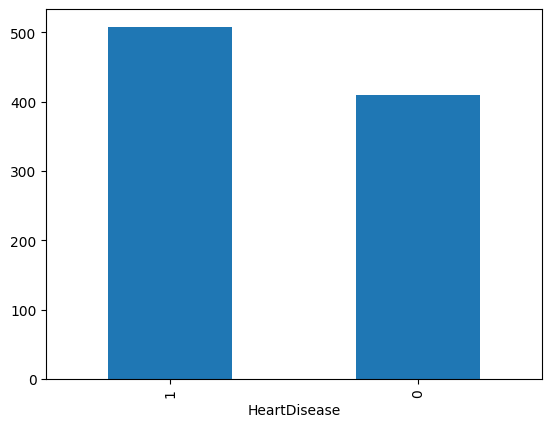

In [11]:
df['HeartDisease'].value_counts().plot(kind="bar")

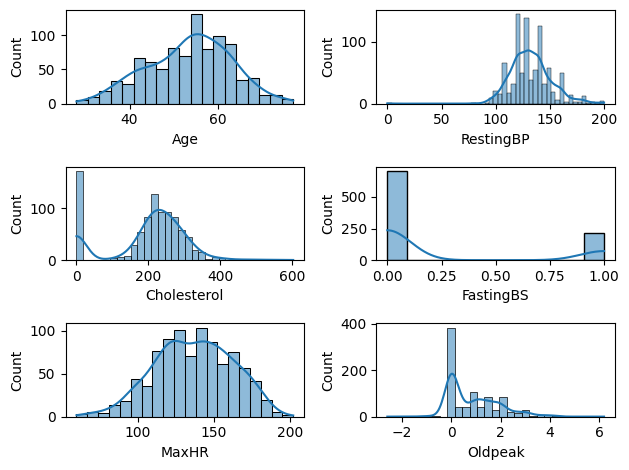

In [12]:
def plotting(var , num):

  plt.subplot(3,2,num)
  sns.histplot(df[var] , kde = True)


plotting('Age' , 1)
plotting('RestingBP' , 2)
plotting('Cholesterol' , 3)
plotting( 'FastingBS' , 4)
plotting('MaxHR' , 5)
plotting('Oldpeak', 6)

plt.tight_layout()

In [13]:
for col in numeric_columns:
  print("<--",col,"-->")
  print(df[col].value_counts())
  print("-----------------------------------------------------------------")

<-- Age -->
Age
54    51
58    42
55    41
56    38
57    38
52    36
62    35
59    35
51    35
53    33
60    32
48    31
61    31
63    30
50    25
41    24
43    24
46    24
64    22
49    21
65    21
47    19
44    19
45    18
42    18
38    16
67    15
39    15
40    13
69    13
66    13
37    11
35    11
68    10
74     7
70     7
34     7
36     6
32     5
71     5
72     4
75     3
29     3
31     2
33     2
77     2
76     2
30     1
28     1
73     1
Name: count, dtype: int64
-----------------------------------------------------------------
<-- RestingBP -->
RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
101      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64
-----------------------------------------------------------------
<-- Cholesterol -->
Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int

In [14]:
#there are some wrong values in Resting BP and cholesterol with value 0..Lets Clean it

In [15]:
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()

In [16]:
ch_mean

np.float64(244.6353887399464)

In [17]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

<Axes: xlabel='Cholesterol', ylabel='Count'>

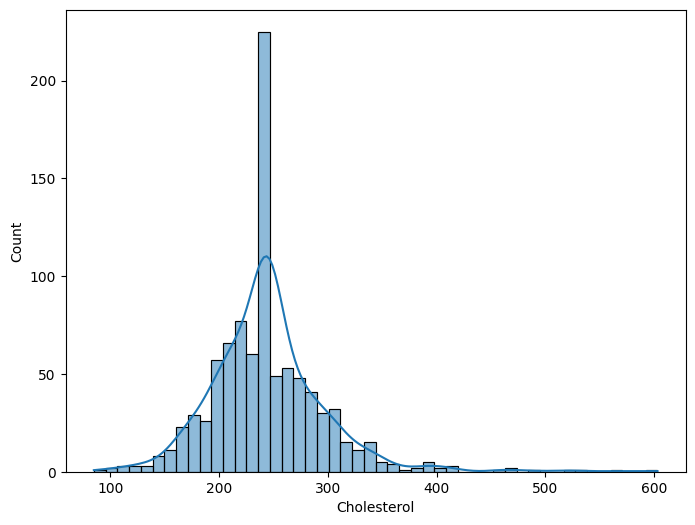

In [18]:
plt.figure(figsize=(8,6))
sns.histplot(df['Cholesterol'],kde = True)


In [19]:
rp_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
rp_mean

np.float64(132.54089422028352)

In [20]:
df['RestingBP'] = df['RestingBP'].replace(0,rp_mean)
df['RestingBP'] = df['RestingBP'].round(2)

<Axes: xlabel='RestingBP', ylabel='Count'>

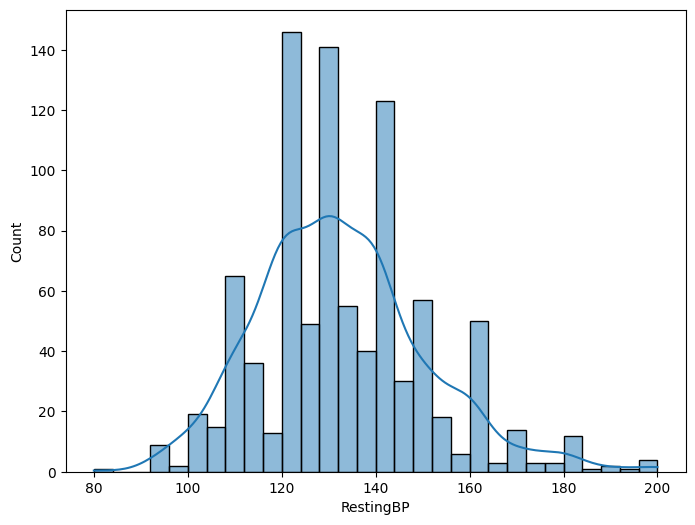

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(df['RestingBP'],kde = True)


In [22]:
cat_columns = df.select_dtypes(include=['object', 'category']).columns

print(cat_columns)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


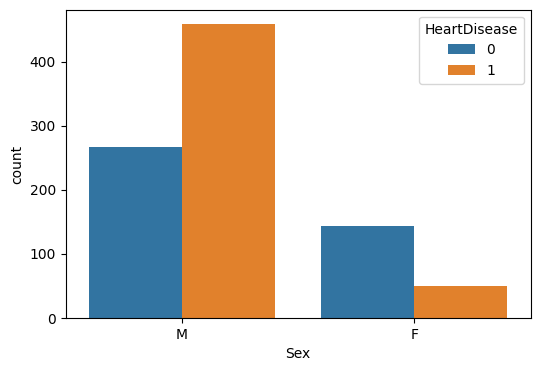

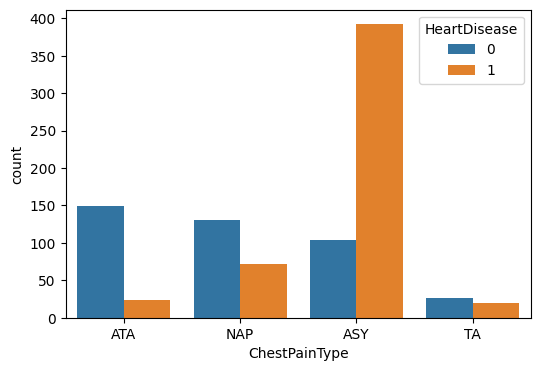

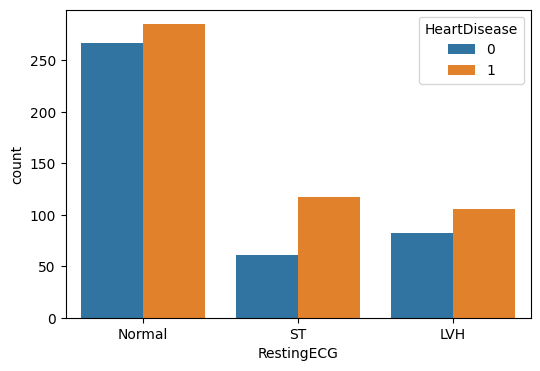

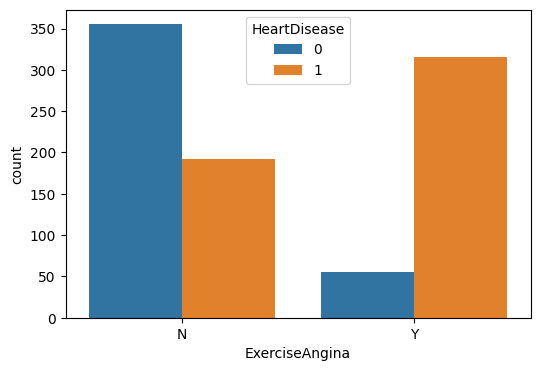

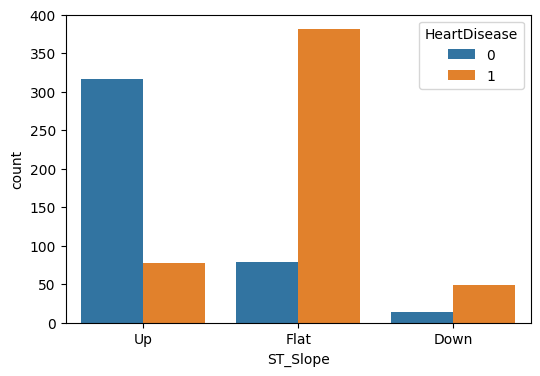

In [23]:
for col in cat_columns:
  plt.figure(figsize=(6,4))
  sns.countplot(x =df[col],hue = df['HeartDisease'])

<Axes: >

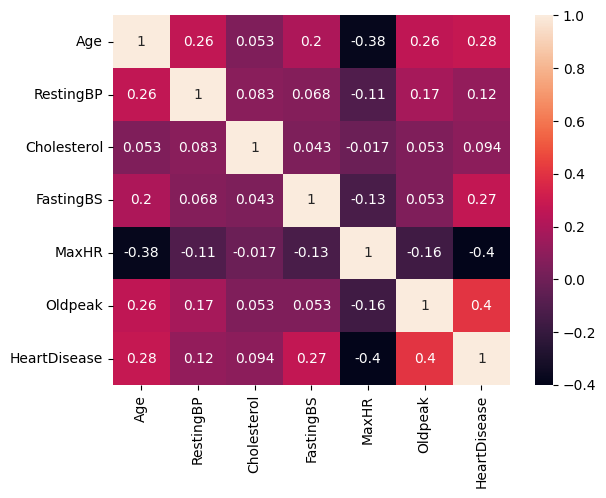

In [24]:
sns.heatmap(df.corr(numeric_only=True) , annot= True)

## **DATA PREPROCESSING**

In [25]:
df_encode = pd.get_dummies(df, drop_first=True)

In [26]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [27]:
df_encode = df_encode.astype(int)

In [28]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [29]:
from sklearn.preprocessing import StandardScaler



In [30]:
scale = StandardScaler()
req_cols = ["Age" , "RestingBP" , "Cholesterol" , "MaxHR" , "Oldpeak"]

df_encode[req_cols] =scale.fit_transform(df_encode[req_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [31]:
from scipy.stats import pearsonr

In [32]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [33]:
selected = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
        'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']

In [34]:
correlations = {
    feature : pearsonr(df_encode[feature] , df_encode['HeartDisease'] ) [0]
    for feature in selected
}

In [35]:
correlation_df = pd.DataFrame(list(correlations.items()) , columns = ['Feature' , 'Pearson Correlation'])
correlation_df.sort_values(by= 'Pearson Correlation' , ascending = False)

,Feature,Pearson Correlation
13,ST_Slope_Flat,0.554134
12,ExerciseAngina_Y,0.494282
5,Oldpeak,0.392385
6,Sex_M,0.305445
0,Age,0.282039
3,FastingBS,0.267291
1,RestingBP,0.117909
11,RestingECG_ST,0.102527
2,Cholesterol,0.092586
9,ChestPainType_TA,-0.054790


In [36]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,-0.902775,-1.253622,0.365619,0,-0.188999,0.282891,1,1,0,0,1,1,0,0,1,0
914,1.536902,0.637353,-0.966725,1,0.164684,2.303858,1,1,0,0,0,1,0,0,1,0
915,0.370100,-0.141284,-2.130180,0,-0.857069,0.282891,1,1,0,0,0,1,0,1,1,0
916,0.370100,-0.141284,-0.159813,0,1.461525,-0.727592,1,0,1,0,0,0,0,0,1,0


# **MODEL BUILDING**

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [41]:
X = df_encode.drop('HeartDisease' , axis = 1)
y = df_encode['HeartDisease']

X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size= 0.2 , random_state= 42)

# **MODELS**

In [47]:
models = {
    "logistic Regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier() ,
    "Naive bayes" : GaussianNB(),
    "Decision Tree" : DecisionTreeClassifier(),
    "SVM" : SVC()
}

In [48]:
result = []

In [52]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_pred , y_test)
    f1 = f1_score(y_pred , y_test)
    result.append({
        'model' : name,
        "accuracy" :round(acc, 4),
        "F1 Score" :round(f1 , 4)
    }
    )

In [55]:
result

[{'model': 'logistic Regression',
  'accuracy': 0.8586956521739131,
  'F1 Score': 0.8737864077669902},
 {'model': 'KNN',
  'accuracy': 0.8369565217391305,
  'F1 Score': 0.8557692307692307},
 {'model': 'Naive bayes',
  'accuracy': 0.8478260869565217,
  'F1 Score': 0.8613861386138614},
 {'model': 'Decision Tree',
  'accuracy': 0.8097826086956522,
  'F1 Score': 0.8241206030150754},
 {'model': 'SVM',
  'accuracy': 0.8478260869565217,
  'F1 Score': 0.8679245283018868},
 {'model': 'logistic Regression', 'accuracy': 0.8587, 'F1 Score': 0.8738},
 {'model': 'KNN', 'accuracy': 0.837, 'F1 Score': 0.8558},
 {'model': 'Naive bayes', 'accuracy': 0.8478, 'F1 Score': 0.8614},
 {'model': 'Decision Tree', 'accuracy': 0.8043, 'F1 Score': 0.82},
 {'model': 'SVM', 'accuracy': 0.8478, 'F1 Score': 0.8679}]